# Data Cleaning for Financials Dataset

In this notebook, we will perform data cleaning on the **Financials.csv** dataset. The steps include:

1. Importing libraries and setting up the environment.
2. Defining helper cleaning functions.
3. Applying the cleaning pipeline on the raw data.
4. Saving the cleaned data in `data/processed/Financials_cleaned.csv`.
5. Optionally, visualizing a boxplot of `sale_price` for a quick inspection.

Let's get started!


## Step 1 – Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# Enable inline plotting in the notebook
%matplotlib inline

## Step 2 – Define Cleaning Functions

Below, we define all the necessary helper functions to clean the data.

In [2]:
def clean_column_names(df):
    """
    Remove leading/trailing spaces from column names,
    convert to lowercase, and replace spaces with underscores.
    """
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
    return df

def convert_parentheses(value):
    """
    Convert numbers enclosed in parentheses to negative numbers.
    For example, "( 4533.75 )" becomes "-4533.75".
    """
    if isinstance(value, str):
        pattern = r"^\(\s*([0-9.,-]+)\s*\)$"
        match = re.match(pattern, value.strip())
        if match:
            inner = match.group(1)
            return "-" + inner
    return value

def clean_numeric_value(x):
    """
    Clean numeric values by:
      - Converting values in parentheses to negative,
      - Removing symbols like '$' and ',',
      - Converting empty strings or '-' to NaN,
      - Finally converting the result to float.
    """
    if isinstance(x, str):
        x = convert_parentheses(x)
        x = x.replace('$', '').replace(',', '')
        if x.strip() == '' or x.strip() == '-':
            return np.nan
        try:
            return float(x)
        except ValueError:
            return np.nan
    elif pd.isna(x):
        return np.nan
    else:
        return x

def clean_numeric_columns(df, cols):
    for col in cols:
        df[col] = df[col].apply(clean_numeric_value)
    return df

def remove_duplicates(df):
    return df.drop_duplicates()

def clean_string_columns(df, cols):
    for col in cols:
        df[col] = df[col].astype(str).str.strip()
    return df

def standardize_categorical(df, cols):
    for col in cols:
        df[col] = df[col].astype(str).str.lower().str.strip()
    return df

def fill_missing_numeric(df, method='median'):
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        if method == 'median':
            df[col] = df[col].fillna(df[col].median())
        elif method == 'mean':
            df[col] = df[col].fillna(df[col].mean())
    return df

def convert_date_column(df, date_col, date_format='%Y-%m-%d'):
    df[date_col] = pd.to_datetime(df[date_col], format=date_format, errors='coerce')
    return df


## Step 3 – Apply the Cleaning Pipeline

This section loads the raw dataset, applies the cleaning functions, and saves the cleaned data.


In [3]:
# Use the correct relative path.
# If your notebook is in "GET/notebooks/", adjust the path accordingly:
raw_path = '../data/raw/Financials.csv'
df = pd.read_csv(raw_path)
print("Loaded data shape:", df.shape)

# --- Step 1: Clean column names ---
df = clean_column_names(df)
print("Columns after cleaning:", df.columns.tolist())

# --- Step 2: Remove duplicates ---
df = remove_duplicates(df)

# --- Step 3: Clean numeric columns ---
numeric_cols = ['units_sold', 'manufacturing_price', 'sale_price', 
                'gross_sales', 'discounts', 'sales', 'cogs', 'profit']
df = clean_numeric_columns(df, numeric_cols)

# --- Step 4: Clean string columns ---
string_cols = ['segment', 'country', 'product', 'discount_band']
df = clean_string_columns(df, string_cols)

# --- Step 5: Convert 'date' column to datetime (if exists) ---
if 'date' in df.columns:
    df = convert_date_column(df, 'date', date_format='%Y-%m-%d')

# --- Step 6: Standardize categorical variables ---
categorical_cols = ['discount_band']  # Adjust if needed
df = standardize_categorical(df, categorical_cols)

# --- Step 7: Fill missing values for numeric columns ---
df = fill_missing_numeric(df, method='median')

print("\nFinal DataFrame info:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())

# Create the output directory if it doesn't exist.
os.makedirs('../data/processed', exist_ok=True)

# Save the cleaned dataset.
df.to_csv('../data/processed/Financials_cleaned.csv', index=False)
print("\nSaved cleaned dataset as '../data/processed/Financials_cleaned.csv'")


Loaded data shape: (700, 16)
Columns after cleaning: ['segment', 'country', 'product', 'discount_band', 'units_sold', 'manufacturing_price', 'sale_price', 'gross_sales', 'discounts', 'sales', 'cogs', 'profit', 'date', 'month_number', 'month_name', 'year']

Final DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   segment              700 non-null    object        
 1   country              700 non-null    object        
 2   product              700 non-null    object        
 3   discount_band        700 non-null    object        
 4   units_sold           700 non-null    float64       
 5   manufacturing_price  700 non-null    float64       
 6   sale_price           700 non-null    float64       
 7   gross_sales          700 non-null    float64       
 8   discounts            700 non-null    floa

## Step 4 – Optional: Visualize Data

We can quickly inspect one of the numeric columns (e.g., `sale_price`) using a boxplot.


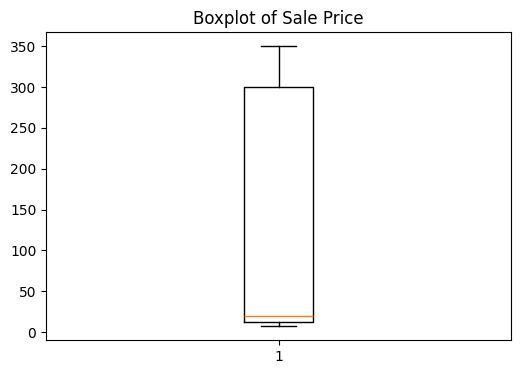

In [4]:
if 'sale_price' in df.columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df['sale_price'].dropna())
    plt.title('Boxplot of Sale Price')
    plt.show()


## Conclusion

The dataset has been cleaned and saved as `../data/processed/Financials_cleaned.csv`.  
You can now proceed to the next steps such as Exploratory Data Analysis (EDA) or modeling.
